In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.optim import AdamW, Adam

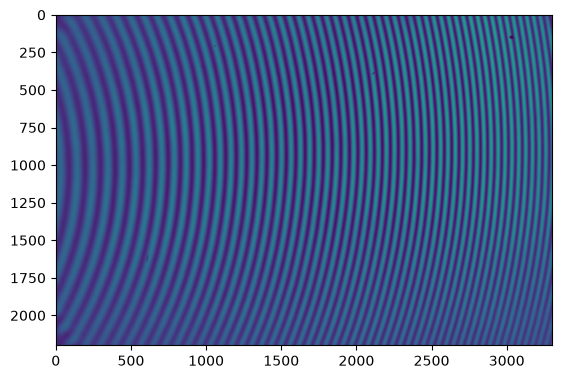

In [2]:
# Read data
data = np.load("../../data/both_arms_piezo_no_delay_20260902_142933.npz")
stack = data["stack"][0]

plt.imshow(stack[0])

converged:     True
kappa_p:       2.22766
kappa_ps:      2.0348
predicted_rms: 0.037099
g_min_ratio:   1
reconstruction_error: 51.2957


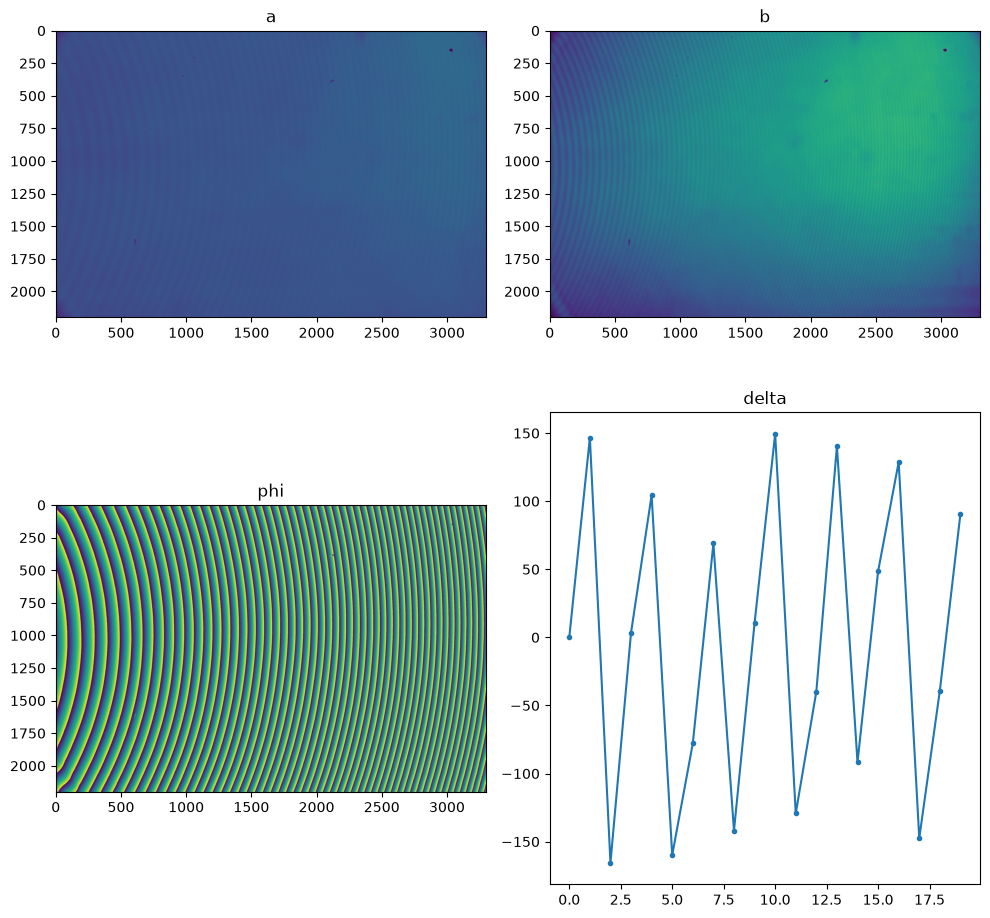

In [18]:
from phase.backend import wrap
from phase import PhaseSolver, PhaseConfig

# AIA test
iters = 30
tol=1e-4


N = 20 # frames to take out of 60
probe_stack = stack[:N, :, :]

cfg_d = PhaseConfig.from_yaml("phase_config.yaml")
cfg_d.use_alpha = False
cfg_d.gain_mode = "none"
cfg_d.precise_reduce = False
cfg_d.method = "aia"
cfg_d.method_kwargs = {"iters": iters, "tol": tol}
solver_d = PhaseSolver(cfg_d)
solver_d.fit(probe_stack)
solver_d.result_.print_summary()

a_map = solver_d.result_.a
b = solver_d.result_.b
phi = solver_d.result_.phi
delta = solver_d.result_.delta
    
plt.figure(figsize=(10, 10))

plt.subplot(221)
plt.title("a")
plt.imshow(a_map)

plt.subplot(222)
plt.title("b")
plt.imshow(b)

plt.subplot(223)
plt.title("phi")
plt.imshow(phi)

plt.subplot(224)
plt.title("delta")
plt.plot(delta/np.pi*180, ".-")

plt.tight_layout()

In [40]:
solver_d.result_.method_param

AIAParam(kappa_p=2.2276559854738753, kappa_ps=2.0347991968450256, predicted_rms=np.float64(0.0370990242778385), iters_run=16, converged=True, g_fit=array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.]), c_fit=array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.]), g_min_ratio=1.0)

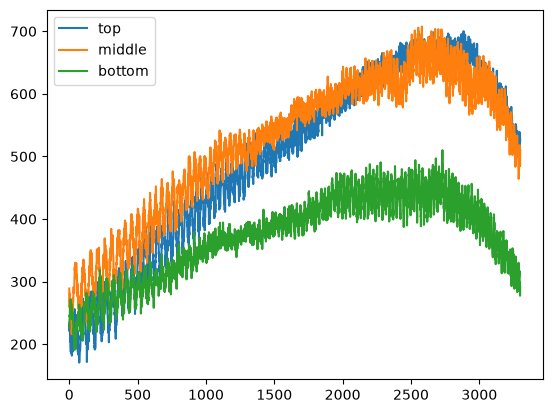

In [7]:
plt.plot(b[250], label="top")
plt.plot(b[1000], label="middle")
plt.plot(b[1750], label="bottom")
plt.legend()

Loss: 332.75946044921875
Loss: 300.37548828125
Loss: 247.23194885253906
Loss: 205.47666931152344
Loss: 152.64114379882812
Loss: 92.45189666748047
Loss: 58.62199401855469
Loss: 53.718101501464844
Loss: 53.70693588256836
Loss: 52.072540283203125
Loss: 51.52476501464844
Loss: 51.317222595214844
Loss: 51.317378997802734
Loss: 51.2957649230957
Loss: 51.28506851196289


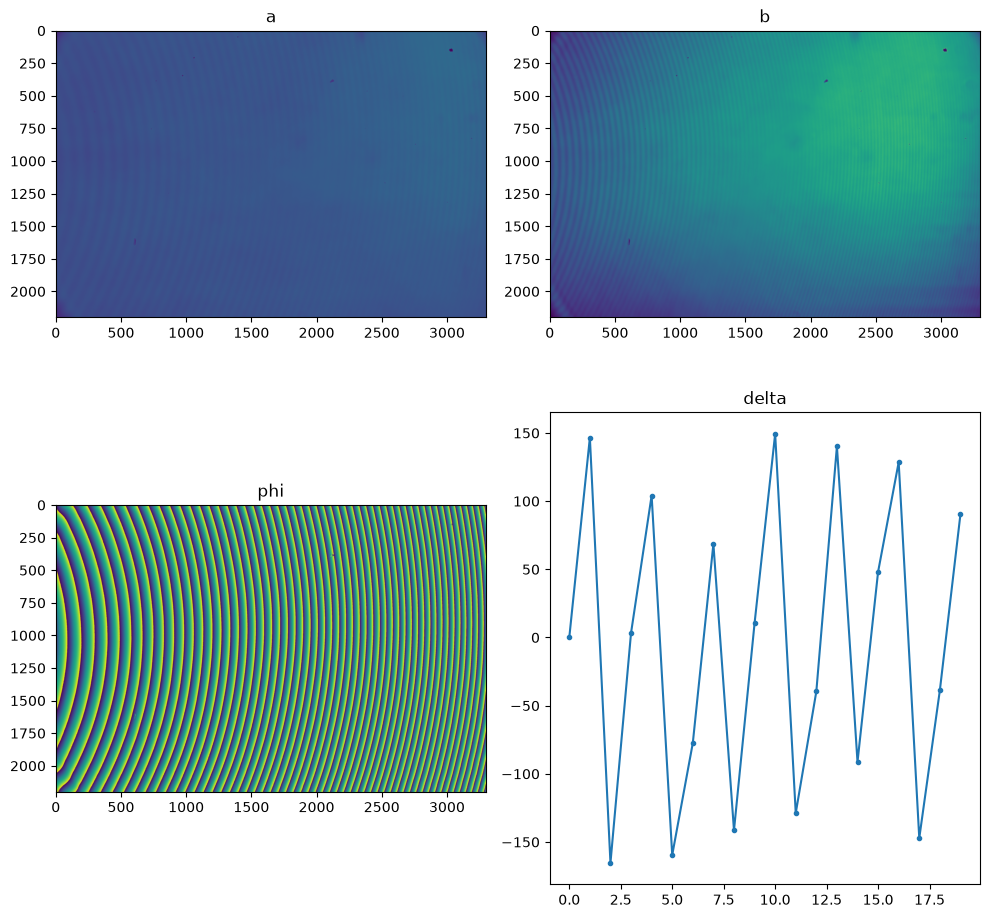

In [20]:
# Grad base approach
iters = 150
dtype = torch.float32
lr = 0.05

N = 20
probe = torch.from_numpy(stack[:N]).to(dtype=dtype)      # (N,H,W)
_, H, W = probe.shape
In = probe.reshape(N, -1)                                 # (N,P)
ones = torch.ones(N, dtype=dtype)

delta_grad = torch.nn.Parameter((torch.arange(N) * 2*np.pi / N).to(dtype=dtype))
opt = Adam([delta_grad], lr=lr)

for it in range(iters):
    opt.zero_grad()
    A = torch.column_stack([ones, torch.cos(delta_grad), torch.sin(delta_grad)])  # (N,3)
    X = torch.linalg.pinv(A) @ In                                       # (3,P), pinv = κ-safe
    loss = torch.mean((In - A @ X)**2)                                  # recon = A@X
    loss.backward()
    opt.step()
    with torch.no_grad(): 
        delta_grad -= delta_grad[0].clone()          # anchor δ[0]=0# wrap to (-π,π], periodic ⇒ safe
        delta_grad.copy_(torch.atan2(torch.sin(delta_grad), torch.cos(delta_grad)))
    if it % 10 == 0:
        print(f"Loss: {torch.sqrt(loss.detach())}")

# params for display only (detached)
with torch.no_grad():
    A = torch.column_stack([ones, torch.cos(delta_grad), torch.sin(delta_grad)])
    a, u, v = torch.linalg.pinv(A) @ In
    a_img   = a.reshape(H, W)
    b_img   = torch.sqrt(u**2 + v**2).reshape(H, W)
    phi_img = torch.atan2(-v, u).reshape(H, W)

plt.figure(figsize=(10, 10))
plt.subplot(221); plt.title("a");     plt.imshow(a_img)
plt.subplot(222); plt.title("b");     plt.imshow(b_img)
plt.subplot(223); plt.title("phi");   plt.imshow(phi_img)
plt.subplot(224); plt.title("delta"); plt.plot(delta_grad.detach()/np.pi*180, ".-")
plt.tight_layout()

Text(0, 0.5, 'MAE of delta, deg')

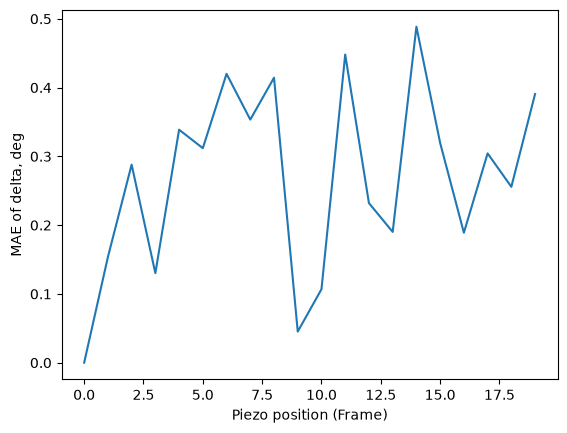

In [24]:
plt.plot(np.abs(delta - np.asarray(delta_grad.detach()))*180/np.pi)
plt.xlabel("Piezo position (Frame)")
plt.ylabel("MAE of delta, deg")

Text(0, 0.5, 'b')

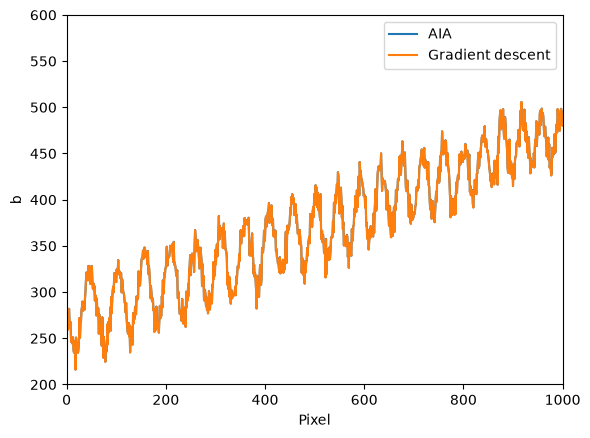

In [36]:
plt.plot(b[1000], label='AIA')
plt.plot(b_img[1000], label='Gradient descent')
plt.xlim([0, 1000])
plt.ylim([200, 600])
plt.legend()
plt.xlabel('Pixel')
plt.ylabel('b')